# Temperature Control Lab: Thermal Conductivity 🌡️♨️

## Introduction
Modern electronic devices generate significant heat, and managing that heat safely is a core engineering challenge. The Temperature Control Lab (TCLab) provides a controlled environment for exploring this problem by simulating a battery and processor separated by a material with unknown thermal properties.

In this project, I used real experimental data from aluminum foil, plastic, and cardboard test pieces to analyze how material choice affects heat transfer between two temperature sensors. I built a physics-based model, validated it against measured data, and explored how thermal conductivity influences steady-state behavior.

This notebook demonstrates full end-to-end engineering and data science workflow:

- Collecting and cleaning experimental data

- Deriving and implementing an ODE model from heat-transfer principles

- Numerically solving the system to simulate temperature dynamics
- Validating the model against real measurements

- Analyzing how thermal conductivity affects T1, T2, and ΔT

- Predicting performance for new materials

## Background
Heat transfer in this system occurs through conduction, convection, and thermal radiation, and each plays a role in shaping the observed temperature behavior. By isolating conduction through the test material, we can evaluate how effectively each material transfers heat from the “processor” (hot side) to the “battery” (cold side).

Thermal conductivity describes how easily heat flows through a material. High-k materials like metals transmit heat quickly, while low-k materials like cardboard act as insulators. Understanding these differences is critical in applications such as smartphones, batteries, and other compact electronics where overheating must be prevented.

This project shows how data science techniques can be applied to a real engineering problem by combining experimental data, physics-based modeling, and numerical simulation.

![Material tests.png](<attachment:Material tests.png>)
 

## Objective

Collect and analyze data from the TCLab to determine how the thermal conductivity of aluminum foil, plastic, and cardboard affects heat transfer between two sensors.
Build and validate a predictive model that can simulate temperature behavior and support material selection decisions in real thermal-design applications.
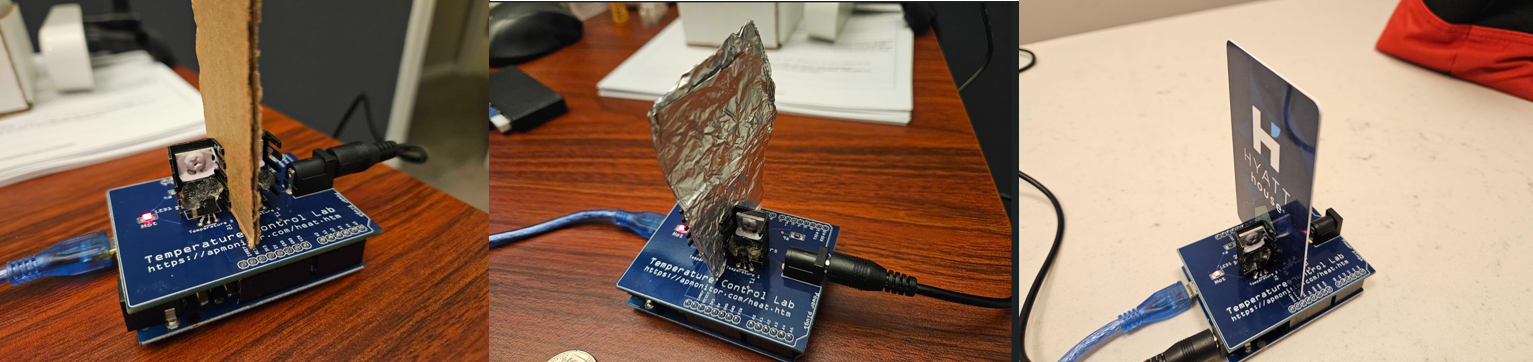



## TCLab Info

The temperature control lab is an application of feedback control with an Arduino, an LED, two heaters, and two temperature sensors. It was developed and created by Professor John Hedengren at APMonitor.com. The heater power output is adjusted to maintain a desired temperature setpoint. Thermal energy from the heater is transferred by conduction, convection, and radiation to the temperature sensor. Heat is also transferred away from the device to the surroundings.

![board-temp sensors.png](<attachment:board-temp sensors.png>)
![TC Lab Annotated.png](<attachment:TC Lab Annotated.png>)


TCLab functions allow Python to interact with the TCLab through the USB serial connection.

![TC Lab Diagram.png](<attachment:TC Lab Diagram.png>)

### Common Functions of the TC Lab
| **TCLab Function** | **Example** | **Description** |
| ----------- | ----------- | ----------- |
| `TCLab()` | `tclab.TCLab()` | Create new lab object and connect |
| `LED` | `lab.LED(45)` | Turn on the LED to 45%. Valid range is 0-100% |
| `Q1` | `lab.Q1(63)` | Turn on heater 1 (`Q1`) to 63%. Valid range is 0-100% |
| `Q2` | `lab.Q2(28)` | Turn on heater 2 (`Q2`) to 28%. Valid range is 0-100% |
| `T1` | `print(lab.T1)` | Read temperature 1 (`T1`) in °C. valid range is -40 to 150°C (TMP36 sensor) |
| `T2` | `print(lab.T2)` | Read temperature 2 (`T2`) in °C. with +/- 1°C accuracy (TMP36 sensor) |
| `close()` | `lab.close()` | Close serial USB connection to TCLab - not needed if using `with` to open |
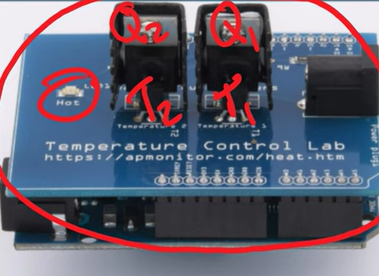
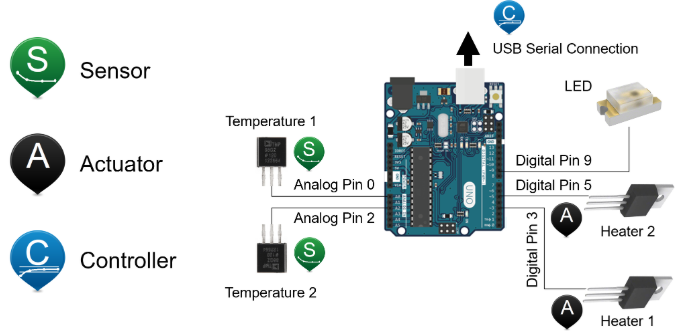
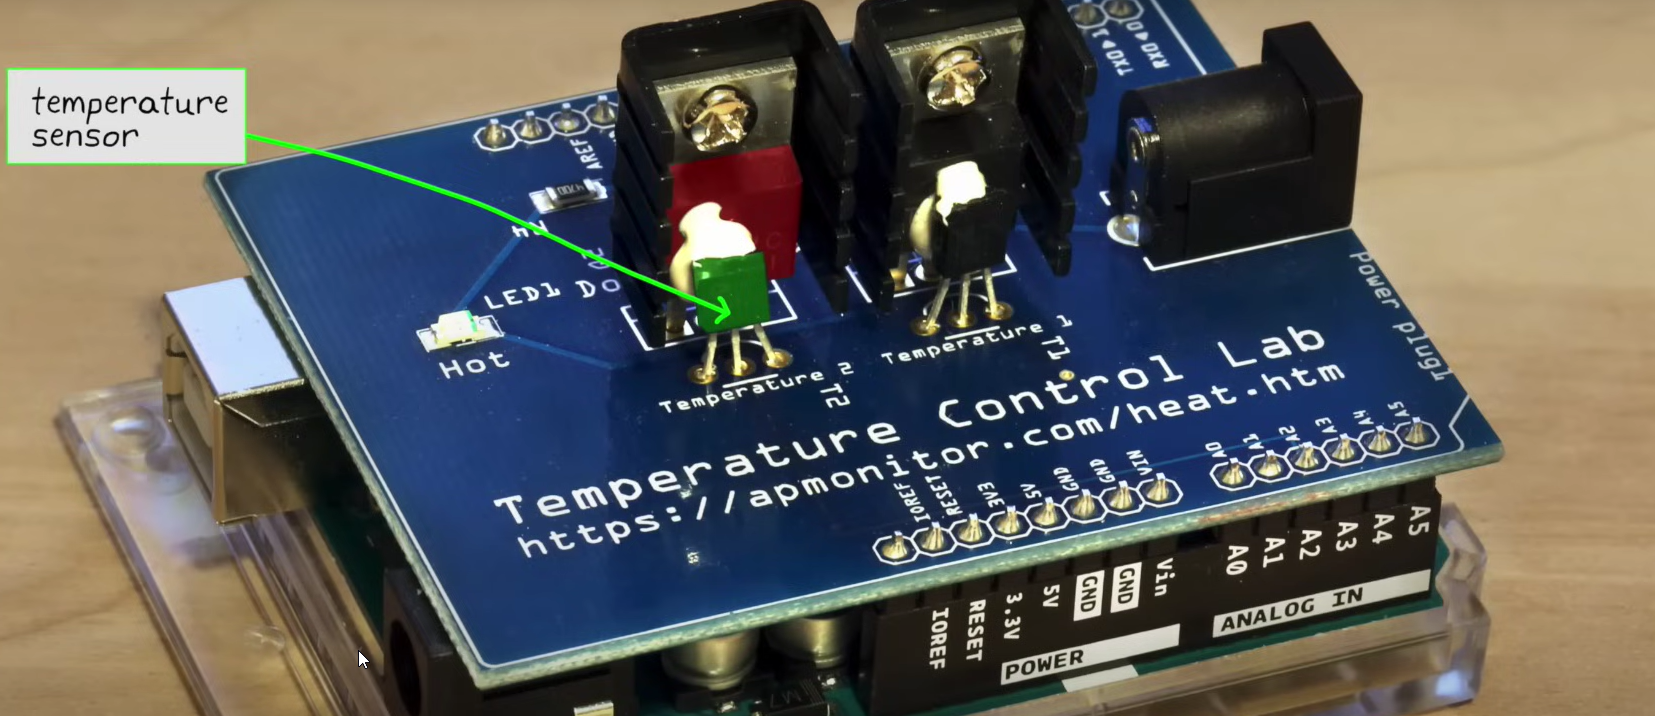

### TCLab Heaters

The temperature of transitor increases as electrical current flows through the small device. Energy is dispersed away from the transitor with two primary mechanisms: convection and radiation. The amount of heat lost by convection $\left(q_{conv}\right)$ is proportional to the temperature difference between the transistor $\left(T_x\right)$ and the surrounding air temperature $\left(T_{air}\right)$.

$q_{conv} = h \, A  \, \left(T_{air}-T_x\right)$

A finned heat sink is attached to the transistor to increase the surface area and increase the heat removal. A temperature sensor is attached to the transistor to monitor the temperature.

<img src='https://apmonitor.com/che263/uploads/Main/TCLab_heater.png'>

The surface area $(A)$ of the transistor and heat sink is about 12 $cm^2$. A convective heat transfer coefficient $(h)$ for quiescent air is approximately 10 $\frac{W}{m^2\,K}$. At lower temperatures, the heat generated by the transistor transfers away from the device primarily by convection but radiative heat transfer $\left(q_{rad}\right)$ may also be a contributing factor. The surrounding temperature $\left(T_\infty\right)$ is that of objects such as walls or the ceiling. In this case is the same as the air temperature.

$q_{rad} = \epsilon \, \sigma \, A  \, \left(T_\infty^4-T_x^4\right)$

Some of the constants needed for the transistor and finned heat sink are shown in the table below. Note that some of the constants in the table are not needed for the calculations.

| ***Quantity*** | ***Value*** |
| --- | --- |
| Heat capacity ($C_p$) | 500 $\frac{J}{kg\,K}$ |
| Air Temperature ($T_{air}$) | 20 $^oC$ |
| Surrounding Temperature ($T_\infty$) | 20 $^oC$ |
| Surface Area ($A$) | 1.2e-3 $m^2$ (12 $cm^2$) |
| Mass ($m$) | 0.004 $kg$ (4 $gm$) |
| Heat Transfer Coefficient ($h$) | 10 $\frac{W}{m^2\,K}$ |
| Emissivity ($\epsilon$)| 0.9 |
| Stefan Boltzmann Constant ($\sigma$) | 5.67e-8 $\frac{W}{m^2-K^4}$ |



## Calculate Convection and Radiation

Before modeling heat transfer through the material, we need to understand how much heat is lost to the ambient environment through convection and radiation. This sets the baseline “leakage” in the system and helps us isolate the effect of conduction through the test material.

Calculate the amount of heat lost by convection and by radiation at temperatures between 20 $^oC$ and 200 $^oC$. Create a plot that shows the heat transfer by each for ```convection``` and ```radiation``` expressions.

```python
convection = h*A*(Ta-Tx)
radiation  = eps*sigma*A*(Tinf**4-Tx**4)
```

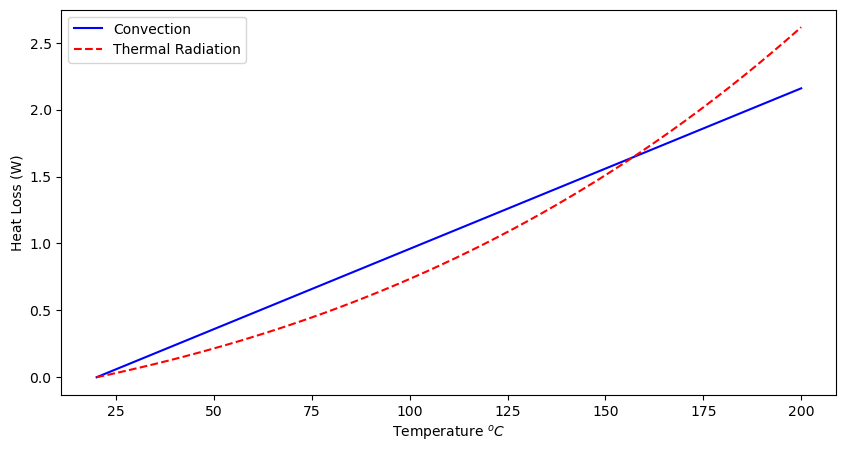

In [24]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

Ta = 20 + 273.15    # Ambient air temperature (K)
Tinf = Ta           # Surrounding temperature (K)
h = 10.0            # Heat Transfer Coefficient (W/m^2-K)
m = 4.0/1000.0      # Mass (kg)
Cp = 0.5 * 1000.0   # Heat capacity (J/kg-K)    
A = 12.0 / 100.0**2 # Surface Area (m^2)
eps = 0.9           # Emissivity
sigma = 5.67e-8     # Stefan-Boltzman

T = np.linspace(20,200) # Temperature (degC)
Tx = T + 273.15     # Temperature (K)

# Energy Balance
convection = h*A*(Ta-Tx)
radiation  = eps*sigma*A*(Tinf**4-Tx**4)

# Save values
pd.DataFrame(np.transpose([-convection, -radiation, T])\
             ,columns=['Convection','Radiation','Temperature'])\
             .to_csv('XX-heat_transfer.csv',index=False)

#Plotting
plt.figure(figsize=(10,5))
plt.plot(T,-convection,'b-',label='Convection')
plt.plot(T,-radiation,'r--',label='Thermal Radiation')
plt.xlabel('Temperature $^oC$')
plt.ylabel('Heat Loss (W)')
plt.legend()
plt.show()

### Radiation exceeds convection as the primary method of heat loss after approx 160 degrees



Determine the temperature where radiative heat transfer is greater than the heat lost by convective heat transfer.


In [ ]:
data=pd.read_csv('XX-heat_transfer.csv')
data.head()

,Convection,Radiation,Temperature
0,-0.000000,-0.000000,20.000000
1,0.044082,0.023098,23.673469
2,0.088163,0.047069,27.346939
3,0.132245,0.071936,31.020408
4,0.176327,0.097720,34.693878


In [17]:
# Find the temperatures where radiation exceeds convection
data[data["Radiation"] > data["Convection"]]["Temperature"]



38    159.591837
39    163.265306
40    166.938776
41    170.612245
42    174.285714
43    177.959184
44    181.632653
45    185.306122
46    188.979592
47    192.653061
48    196.326531
49    200.000000
Name: Temperature, dtype: float64

### Takeaway: Radiation exceed convection at 159.9 Degrees

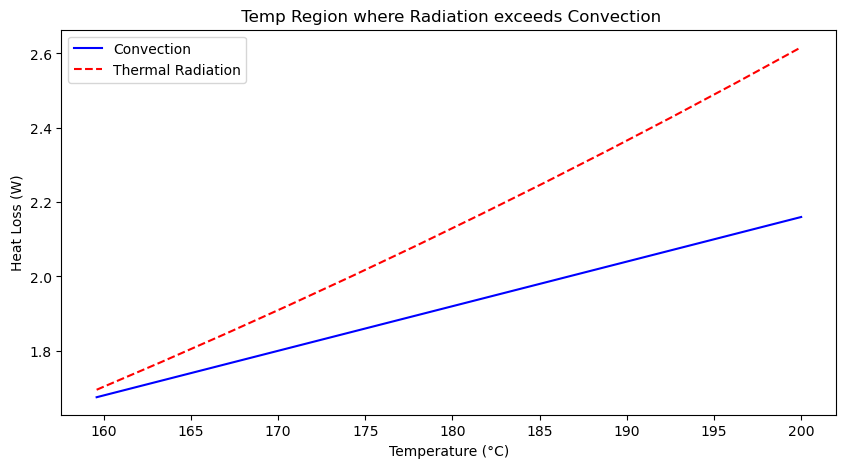

In [19]:
mask = data["Radiation"] > data["Convection"]
region = data[mask]

plt.figure(figsize=(10,5))
plt.plot(region["Temperature"], region["Convection"], 'b-', label='Convection')
plt.plot(region["Temperature"], region["Radiation"], 'r--', label='Thermal Radiation')
plt.xlabel("Temperature (°C)")
plt.ylabel("Heat Loss (W)")
plt.legend()
plt.title(" Temp Region where Radiation exceeds Convection")
plt.show()


### Takeaway: Thermal radiation then rapidly exceeds convection as the primary heat loss method above 160°C
In the TCLab experiments, temperatures will stay well below this crossover point, so convection and conduction dominate and will allow for a simplified ODE model used later in this project

Equation for convection heat loss:
$q_{conv} = h \, A  \, \left(T_{air}-T_x\right)$

Equation for radiation heat loss:
$q_{rad} = \epsilon \, \sigma \, A  \, \left(T_\infty^4-T_x^4\right)$





## Thermal Conductivity Tests

Insert materials: plastic (PVC hotel room key), cardboard and aluminum foil in between the two heaters so that there is a conduction path for heat between the two sensors. The temperature difference and temperature levels are affected by the ability of the material to conduct heat from heater 1 and temperature sensor $(T_1)$ to the other temperature sensor $(T_2)$.

When changing out the materials between the heaters, wait until the heaters have cooled off and avoid touching a hot surface. There are thermochromic paint dots on the heaters that turn pink when the heaters are above 37 °C (99 °F)

Turn on heater 1 to 100% and record $T_1$, $T_2$, and the temperature difference $\Delta T = T_1-T_2$ every 10 seconds for 8 minutes for each material (6 x 8 + 1 = 49 data points). The objective is to observe the temperatures at steady state conditions and longer or shorter tests may be required to reach steady state. For each material test, record the values at the end after the system has reached a steady state equilibrium.
![Material tests.png](<attachment:Material tests.png>)


With the experimental setup defined, the next step is to evaluate each material individually. For each test piece- plastic, cardboard, and aluminum foil,  I collected time-series temperature data, visualized the thermal response, and then calculated its effective thermal conductivity

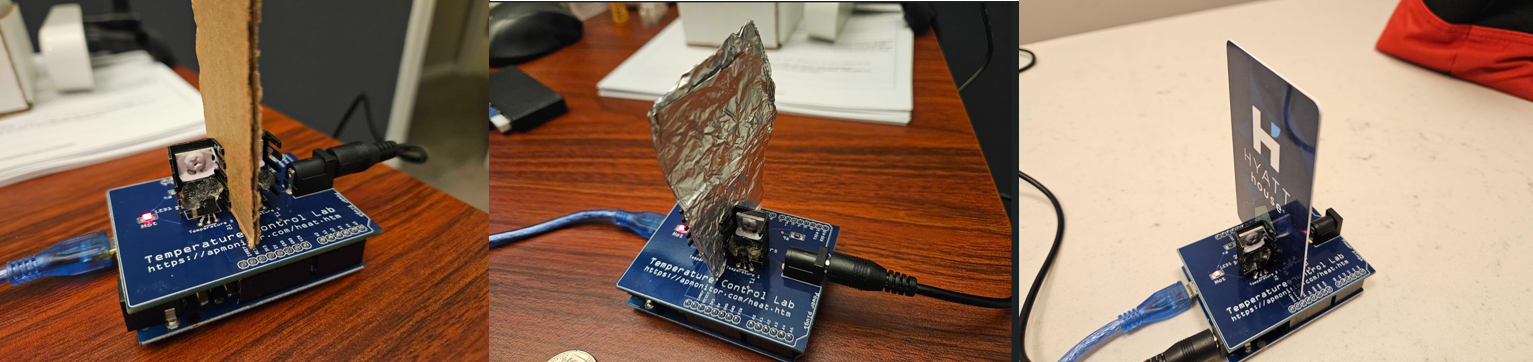

### Room Key (PVC Plastic)

![room key side.jpg](<attachment:room key side.jpg>)
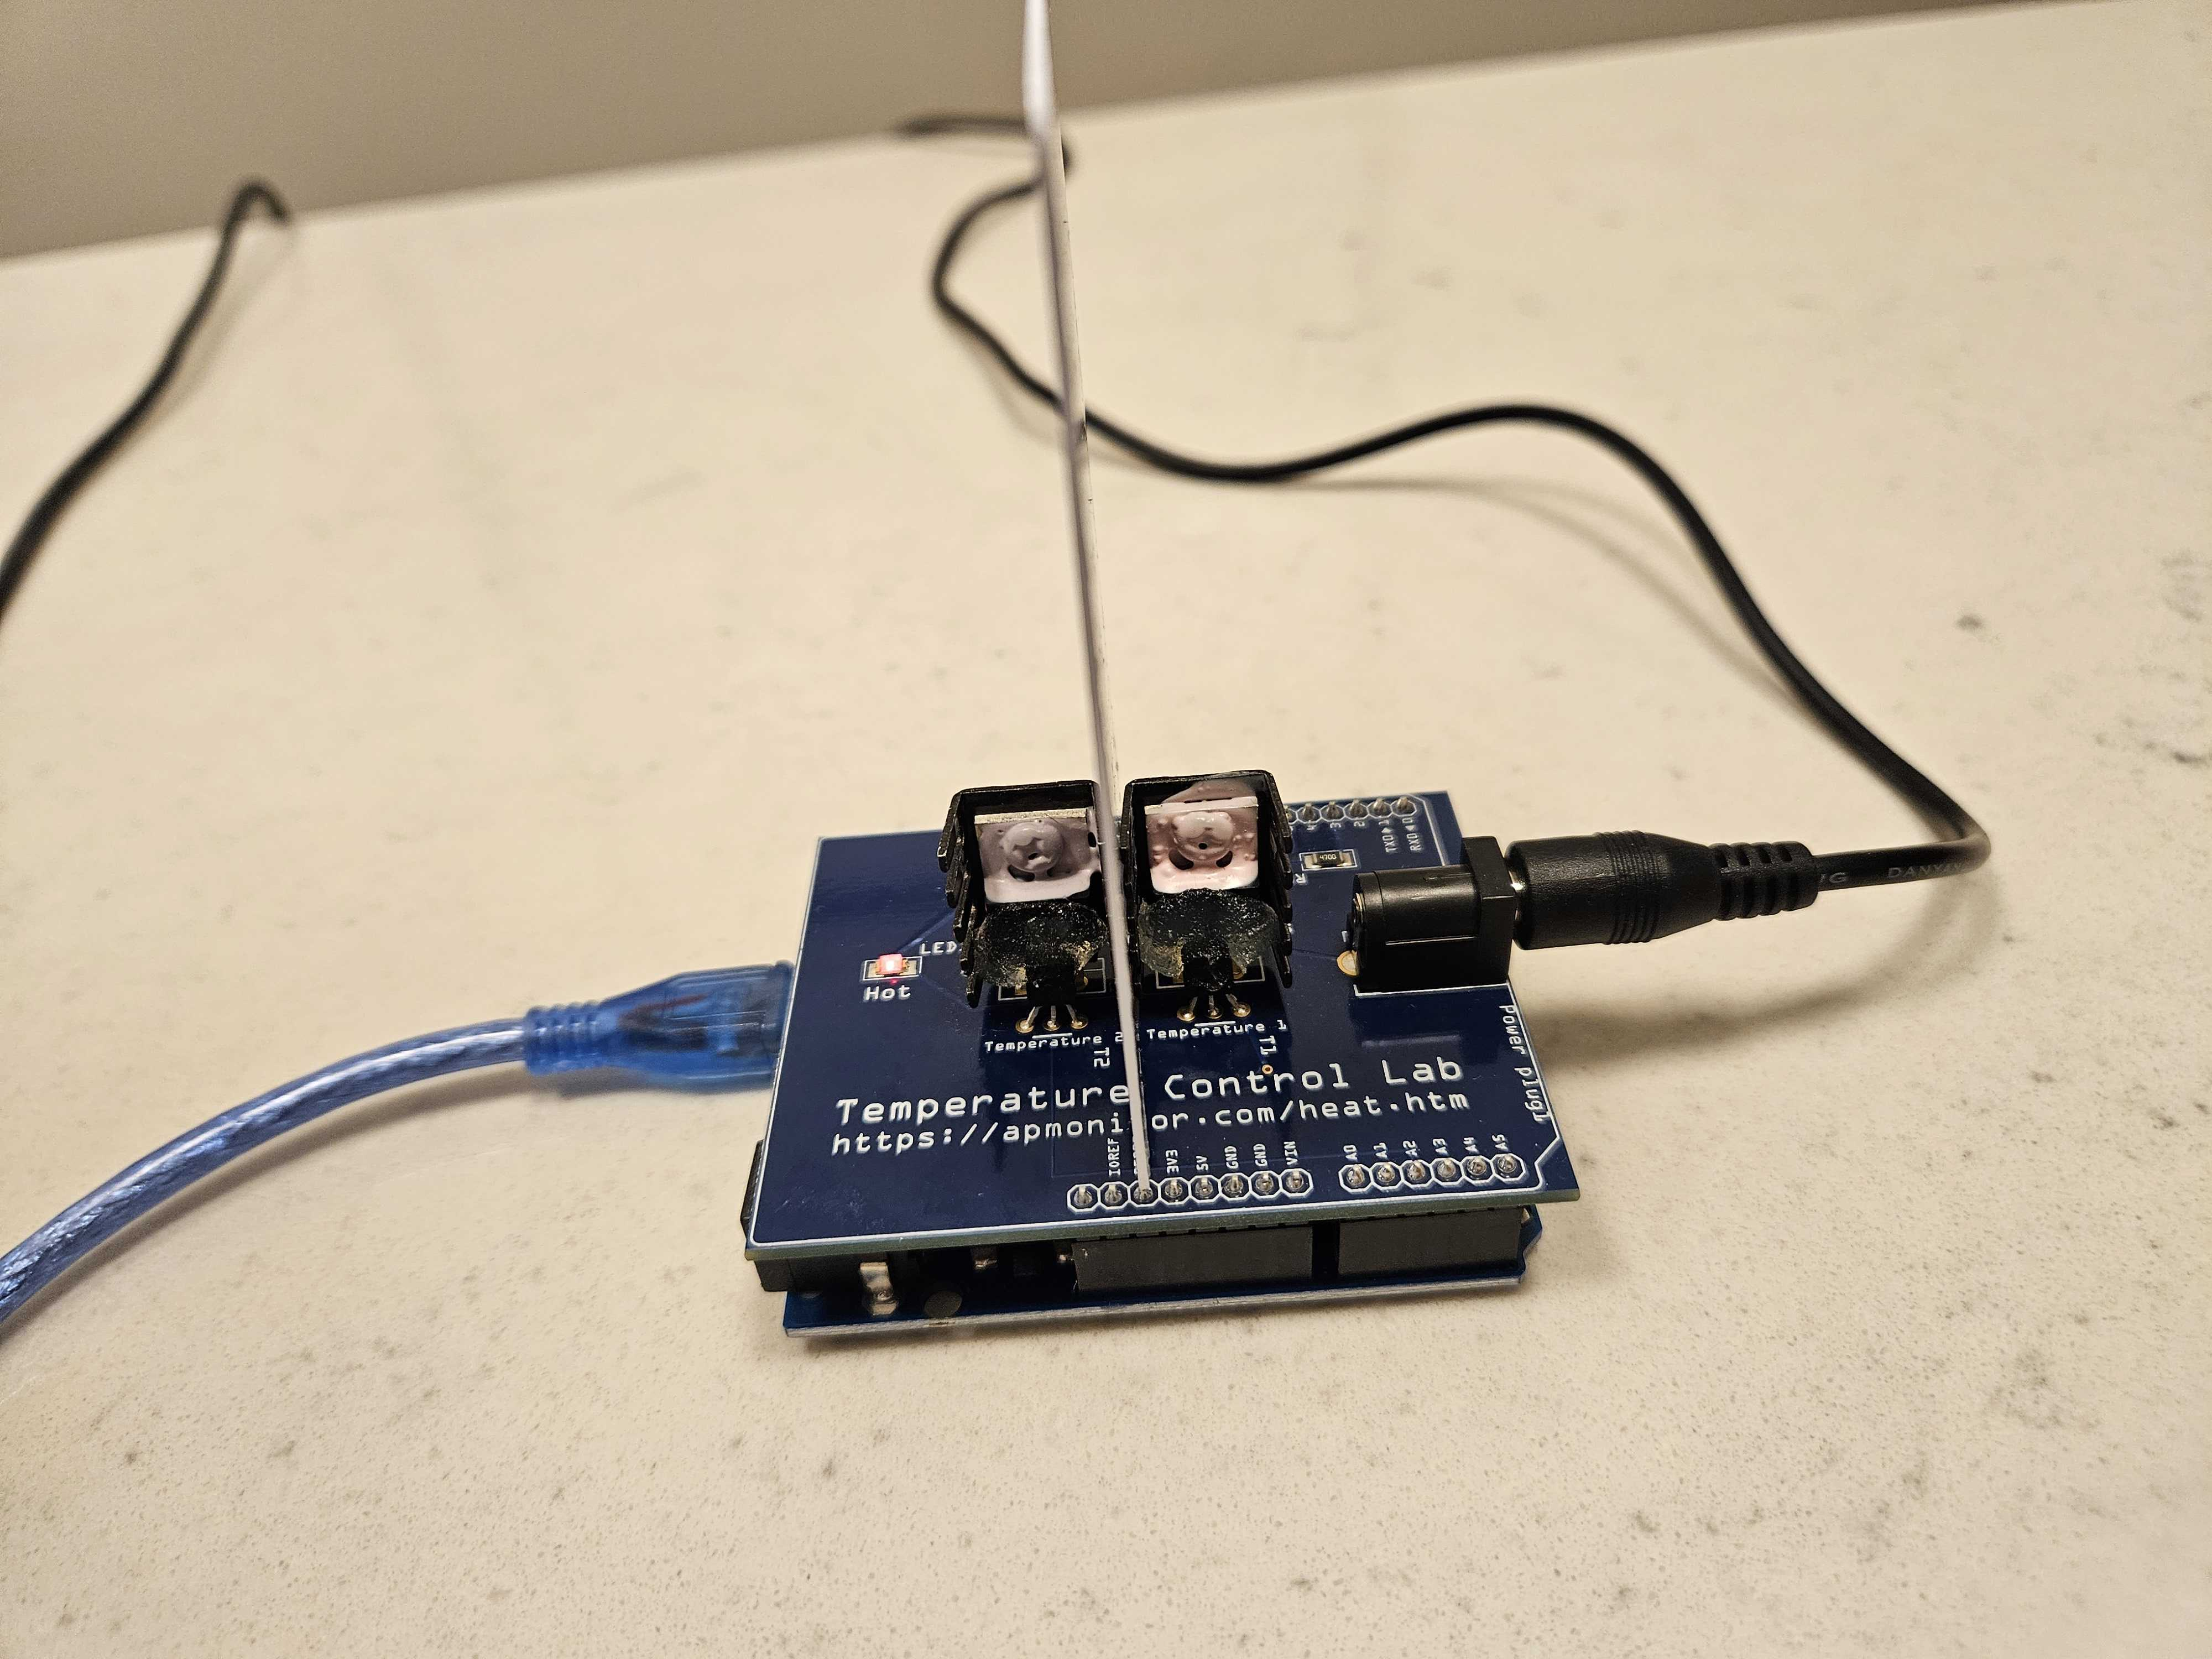

In [21]:
# First thermal conductivity test- hotel room key
import tclab, time
import numpy as np
import pandas as pd

#setup 
material = 'RoomKey'
test_num = 1
filename  = f"{material}_test{test_num}.csv"

# initialize
n = 49
tm = np.linspace(0,480, n) # 8 min at 10 sec intervals
T1 = [] ; T2 = [] ; Tdif = []

with tclab.TCLab() as lab:
    lab.Q1(100) # Heater 1 at 100%
    for i in range(n):
        T1.append(lab.T1)  # Log Sensor 1
        T2.append(lab.T2)  # Log Sensor 2
        Tdif.append(lab.T1 - lab.T2)  # Log temp difference
        print(tm[i], T1[i], T2[i], Tdif[i])  # Print results
        time.sleep(10)  # Wait 10 seconds
# Save to CSV      
data = np.column_stack((tm,T1,T2, Tdif))
df = pd.DataFrame(data,columns=['Time', 'T1', 'T2', 'T1-T2'])
df.to_csv(filename,index=False)

TCLab version 1.0.0
Arduino Leonardo connected on port COM7 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
0.0 21.833 21.865 -0.06400000000000006
10.0 21.897 21.801 0.12900000000000134
20.0 23.348 21.994 1.2240000000000002
30.0 25.185 22.155 3.254999999999999
40.0 27.408 22.188 5.253
50.0 30.438 22.51 7.734999999999999
60.0 32.887 22.832 10.151
70.0 35.723 23.315 12.278999999999996
80.0 38.494 24.057 14.599
90.0 41.33 24.669 16.628999999999998
100.0 43.199 25.152 18.015
110.0 46.164 26.055 20.174
120.0 48.517 26.86 21.591
130.0 50.547 27.634 23.009999999999998
140.0 52.932 28.568 24.491999999999997
150.0 54.865 29.277 25.588
160.0 56.187 29.954 26.394
170.0 58.185 30.792 27.456999999999997
180.0 59.087 31.469 27.844
190.0 60.892 32.371 28.552
200.0 61.891 33.048 28.939999999999998
210.0 63.309 33.854 29.552
220.0 64.598 34.659 30.003
230.0 65.532 35.368 30.324999999999996
240.0 67.272 36.367 30.583000000000006
250.0 68.046 37.044 31.001999999999995
260.0 68.626 37.495 31.

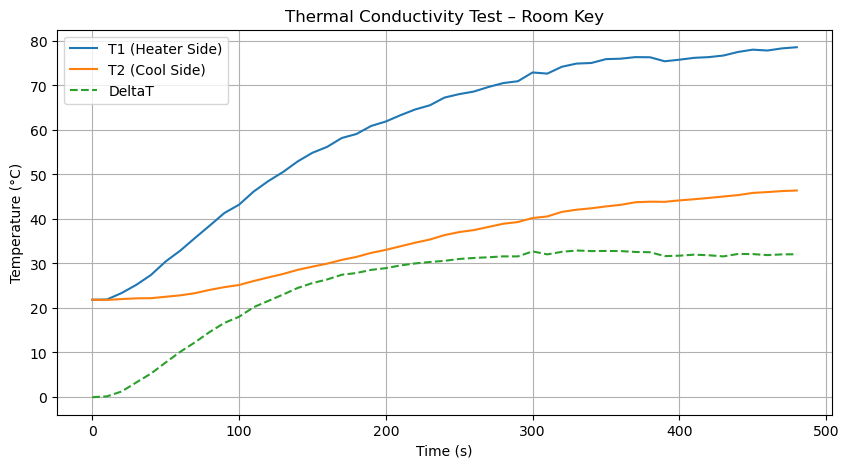

In [ ]:
# Thermal Response
df = pd.read_csv('RoomKey_test1.csv')

plt.figure(figsize=(10,5))
plt.plot(df["Time"], df["T1"], label="T1 (Heater Side)")
plt.plot(df["Time"], df["T2"], label="T2 (Cool Side)")
plt.plot(df["Time"], df["T1-T2"], label="DeltaT", linestyle='--')

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Thermal Conductivity Test – Room Key")
plt.legend()
plt.grid(True)
plt.show()


### Thermal Conductivity Calculation
To compare materials quantitatively, we need an approximate value for their thermal conductivity k. 
At steady state, the temperature difference T2-T1. directly linked to how efficiently each material conducts heat.



- Assume 1 Watt output from the heater (Q)
- Distance between heater 1 and heater 2 is 15 cm
- Area is 12 cm^2

 Using Fourier’s Law for 1D conduction: rearrange the equation to solve for thermal conductivity (k) for each material



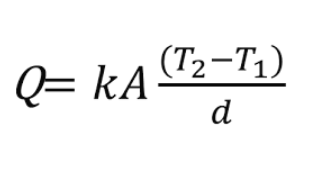
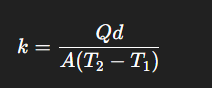


In [ ]:
# Calculate thermal conductivity of room key
d = 0.015 # thickness in meters
A = 12.0 / 100.0**2 # Surface Area (m^2)
Q = 1 # Power input (W)

k = (Q * d) / (A * df["T1-T2"].max())
print(f"Thermal Conductivity k = {k:.2f} W/m-K")

Thermal Conductivity k = 0.38 W/m-K


In [28]:
# Second thermal conductivity test- hotel room key
import tclab, time
import numpy as np
import pandas as pd

#setup 
material = 'RoomKey'
test_num = 2
filename  = f"{material}_test{test_num}.csv"

# initialize
n = 49
tm = np.linspace(0,480, n) # 8 min at 10 sec intervals
T1 = [] ; T2 = [] ; Tdif = []

with tclab.TCLab() as lab:
    lab.Q1(100) # Heater 1 at 100%
    for i in range(n):
        T1.append(lab.T1)  # Log Sensor 1
        T2.append(lab.T2)  # Log Sensor 2
        Tdif.append(lab.T1 - lab.T2)  # Log temp difference
        print(tm[i], T1[i], T2[i], Tdif[i])  # Print results
        time.sleep(10)  # Wait 10 seconds
# Save to CSV      
data = np.column_stack((tm,T1,T2, Tdif))
df = pd.DataFrame(data,columns=['Time', 'T1', 'T2', 'T1-T2'])
df.to_csv(filename,index=False)

TCLab version 1.0.0
Arduino Leonardo connected on port COM7 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
0.0 19.416 20.834 -1.5459999999999994
10.0 19.448 20.608 -1.0959999999999965
20.0 20.931 20.705 0.12900000000000134
30.0 22.703 20.802 1.9649999999999999
40.0 25.185 21.06 4.317999999999998
50.0 27.988 21.35 6.542000000000002
60.0 30.824 21.769 8.959000000000003
70.0 33.66 22.188 11.440000000000001
80.0 36.496 22.8 13.600000000000001
90.0 39.493 23.509 15.854999999999997
100.0 41.749 24.186 17.531000000000002
110.0 44.392 25.088 19.336
120.0 46.809 25.926 20.819000000000003
130.0 48.742 26.699 21.977999999999998
140.0 51.03 27.634 23.396
150.0 52.706 28.439 24.364
160.0 54.479 29.342 25.105000000000004
170.0 56.509 30.309 26.199999999999996
180.0 57.895 31.114 26.715999999999998
190.0 59.731 32.146 27.747
200.0 61.278 33.016 28.231
210.0 62.084 33.725 28.552999999999997
220.0 63.309 34.434 28.616999999999997
230.0 64.275 35.304 29.003999999999998
240.0 65.468 36.077 

In [ ]:
# Calculate thermal conductivity (2nd test)
d = 0.015 # thickness in meters
A = 12.0 / 100.0**2 # Surface Area (m^2)
Q = 1 # Power input (W)

k = (Q * d) / (A * df["T1-T2"].max())
print(f"Thermal Conductivity k = {k:.2f} W/m-K")

Thermal Conductivity k = 0.40 W/m-K


### Takeaway: The plastic’s average thermal conductivity is 0.39 W/m·K, indicating it is a weak heat conductor and therefore a decent insulator.


### Calculating Thermal Conductivity of Corrugated Cardboard
![cardboard (2).jpg](<attachment:cardboard (2).jpg>)

In [2]:
# First thermal conductivity test- corrugated cardboard
import tclab, time
import numpy as np
import pandas as pd

#setup 
material = 'CorrCardboard'
test_num = 1
filename  = f"{material}_test{test_num}.csv"

# initialize
n = 49
tm = np.linspace(0,480, n) # 8 min at 10 sec intervals
T1 = [] ; T2 = [] ; Tdif = []

with tclab.TCLab() as lab:
    lab.Q1(100) # Heater 1 at 100%
    for i in range(n):
        T1.append(lab.T1)  # Log Sensor 1
        T2.append(lab.T2)  # Log Sensor 2
        Tdif.append(lab.T1 - lab.T2)  # Log temp difference
        print(tm[i], T1[i], T2[i], Tdif[i])  # Print results
        time.sleep(10)  # Wait 10 seconds
# Save to CSV      
data = np.column_stack((tm,T1,T2, Tdif))
df = pd.DataFrame(data,columns=['Time', 'T1', 'T2', 'T1-T2'])
df.to_csv(filename,index=False)

TCLab version 1.0.0
Arduino Leonardo connected on port COM10 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
0.0 20.383 20.512 0.19299999999999784
10.0 20.641 20.544 0.2579999999999991
20.0 22.284 20.576 1.934000000000001
30.0 24.411 20.576 3.8679999999999986
40.0 27.118 20.898 5.866
50.0 29.664 21.188 8.605
60.0 32.79 21.446 11.343000000000004
70.0 35.433 21.994 13.826
80.0 38.365 22.381 16.273999999999997
90.0 41.395 23.122 18.401000000000003
100.0 44.456 23.734 20.689999999999998
110.0 47.034 24.347 22.654999999999998
120.0 49.387 25.023 24.492
130.0 51.9 25.732 26.072000000000003
140.0 53.931 26.409 27.554
150.0 56.315 27.086 28.714
160.0 58.217 27.924 30.389
170.0 60.247 28.633 31.55
180.0 61.955 29.31 32.548
190.0 63.244 30.115 33.033
200.0 64.63 30.792 33.999
210.0 66.112 31.308 35.288000000000004
220.0 67.563 32.081 35.772000000000006
230.0 69.109 32.822 36.416
240.0 70.463 33.467 36.996
250.0 71.526 34.176 37.383
260.0 72.654 34.82 37.800999999999995
270.0 73.524 

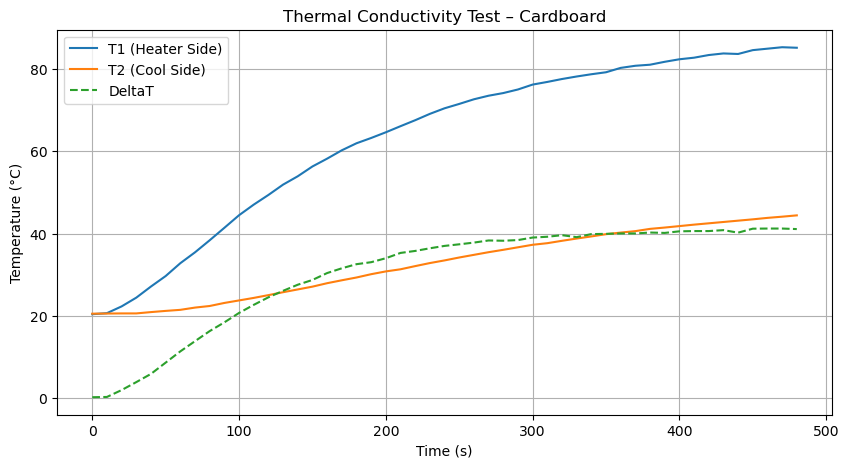

In [4]:
import matplotlib.pyplot as plt
df = pd.read_csv('CorrCardboard_test1.csv')

plt.figure(figsize=(10,5))
plt.plot(df["Time"], df["T1"], label="T1 (Heater Side)")
plt.plot(df["Time"], df["T2"], label="T2 (Cool Side)")
plt.plot(df["Time"], df["T1-T2"], label="DeltaT", linestyle='--')

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Thermal Conductivity Test – Cardboard")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Calculate thermal conductivity (corrugated cardboard)
d = 0.015 # thickness in meters
A = 12.0 / 100.0**2 # Surface Area (m^2)
Q = 1 # Power input (W)

k = (Q * d) / (A * df["T1-T2"].max())
print(f"Thermal Conductivity k = {k:.2f} W/m-K")

Thermal Conductivity k = 0.30 W/m-K


### Takeway:
Cardboard’s k = 0.30 W/m·K, making it an even poorer heat conductor than plastic and a stronger insulator.

### Calculating Thermal Conductivity of Tinfoil

In [9]:
# First thermal conductivity test- tinfoil
import tclab, time
import numpy as np
import pandas as pd

#setup 
material = 'Tinfoil'
test_num = 1
filename  = f"{material}_test{test_num}.csv"

# initialize
n = 49
tm = np.linspace(0,480, n) # 8 min at 10 sec intervals
T1 = [] ; T2 = [] ; Tdif = []

with tclab.TCLab() as lab:
    lab.Q1(100) # Heater 1 at 100%
    for i in range(n):
        T1.append(lab.T1)  # Log Sensor 1
        T2.append(lab.T2)  # Log Sensor 2
        Tdif.append(lab.T1 - lab.T2)  # Log temp difference
        print(tm[i], T1[i], T2[i], Tdif[i])  # Print results
        time.sleep(10)  # Wait 10 seconds
# Save to CSV      
data = np.column_stack((tm,T1,T2, Tdif))
df = pd.DataFrame(data,columns=['Time', 'T1', 'T2', 'T1-T2'])
df.to_csv(filename,index=False)

TCLab version 1.0.0
Arduino Leonardo connected on port COM10 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
0.0 22.059 22.155 -0.12899999999999778
10.0 23.025 22.188 0.870000000000001
20.0 24.314 22.188 2.1590000000000025
30.0 26.055 22.413 4.093
40.0 28.504 22.51 5.864999999999998
50.0 31.179 22.896 8.25
60.0 33.692 23.444 10.216000000000001
70.0 36.013 23.928 11.988000000000003
80.0 38.559 24.637 13.889999999999997
90.0 40.621 25.41 15.179000000000002
100.0 42.394 26.022 16.628999999999998
110.0 44.424 26.731 17.757
120.0 46.325 27.569 18.723000000000003
130.0 47.969 28.311 19.529000000000003
140.0 49.354 28.987 19.916
150.0 50.676 29.857 20.624999999999996
160.0 51.739 30.534 21.27
170.0 52.964 31.211 21.721000000000004
180.0 53.931 32.049 21.592000000000006
190.0 55.026 32.79 22.107999999999997
200.0 56.025 33.37 22.461999999999996
210.0 56.831 34.111 22.720000000000006
220.0 57.54 34.659 23.042
230.0 58.023 35.078 23.139000000000003
240.0 58.926 35.658 23.20300000000

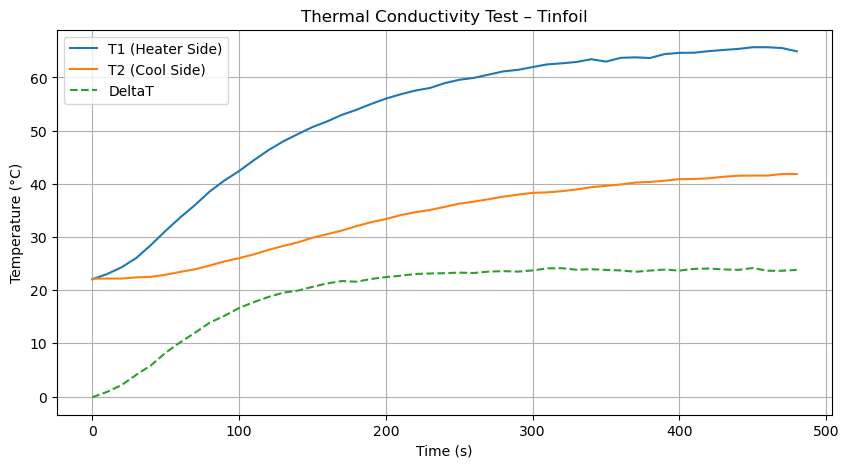

In [10]:
import matplotlib.pyplot as plt
df = pd.read_csv('Tinfoil_test1.csv')

plt.figure(figsize=(10,5))
plt.plot(df["Time"], df["T1"], label="T1 (Heater Side)")
plt.plot(df["Time"], df["T2"], label="T2 (Cool Side)")
plt.plot(df["Time"], df["T1-T2"], label="DeltaT", linestyle='--')

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Thermal Conductivity Test – Tinfoil")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Calculate thermal conductivity (tinfoil)
d = 0.015 # thickness in meters
A = 12.0 / 100.0**2 # Surface Area (m^2)
Q = 1 # Power input (W)

k = (Q * d) / (A * df["T1-T2"].max())
print(f"Thermal Conductivity k = {k:.2f} W/m-K")

Thermal Conductivity k = 0.52 W/m-K


In [12]:
# Second thermal conductivity test- tinfoil
import tclab, time
import numpy as np
import pandas as pd

#setup 
material = 'Tinfoil'
test_num = 2
filename  = f"{material}_test{test_num}.csv"

# initialize
n = 49
tm = np.linspace(0,480, n) # 8 min at 10 sec intervals
T1 = [] ; T2 = [] ; Tdif = []

with tclab.TCLab() as lab:
    lab.Q1(100) # Heater 1 at 100%
    for i in range(n):
        T1.append(lab.T1)  # Log Sensor 1
        T2.append(lab.T2)  # Log Sensor 2
        Tdif.append(lab.T1 - lab.T2)  # Log temp difference
        print(tm[i], T1[i], T2[i], Tdif[i])  # Print results
        time.sleep(10)  # Wait 10 seconds
# Save to CSV      
data = np.column_stack((tm,T1,T2, Tdif))
df = pd.DataFrame(data,columns=['Time', 'T1', 'T2', 'T1-T2'])
df.to_csv(filename,index=False)

TCLab version 1.0.0
Arduino Leonardo connected on port COM10 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
0.0 22.252 21.833 0.4190000000000005
10.0 22.671 21.865 0.870000000000001
20.0 23.831 21.93 1.6110000000000007
30.0 25.894 22.188 3.8029999999999973
40.0 28.311 22.445 5.832999999999998
50.0 30.824 22.832 8.25
60.0 33.273 23.187 10.152000000000001
70.0 35.594 23.831 11.600999999999999
80.0 37.721 24.54 13.405999999999999
90.0 39.396 25.313 14.598999999999997
100.0 41.91 26.055 15.372
110.0 43.65 26.925 16.79
120.0 45.391 27.698 17.852999999999998
130.0 47.002 28.633 18.046
140.0 48.484 29.567 18.851999999999997
150.0 49.838 30.244 18.980999999999998
160.0 51.159 31.114 19.819000000000003
170.0 52.158 31.888 20.529
180.0 53.447 32.661 20.430999999999997
190.0 54.479 33.241 21.043999999999997
200.0 55.703 33.821 21.914
210.0 56.605 34.466 22.204
220.0 56.992 35.078 21.720999999999997
230.0 57.733 35.723 22.236000000000004
240.0 58.475 36.367 22.075000000000003
250.0 5

In [ ]:
# Calculate thermal conductivity (tinfoil-test2)
d = 0.015 # thickness in meters
A = 12.0 / 100.0**2 # Surface Area (m^2)
Q = 1 # Power input (W)

k = (Q * d) / (A * df["T1-T2"].max())
print(f"Thermal Conductivity k = {k:.2f} W/m-K")

Thermal Conductivity k = 0.54 W/m-K


### Takeaway:
Aluminum foil’s k ≈ 0.53 W/m·K, making it the best heat conductor of the three materials.



## Interpreting Material Behavior Through Thermal Conductivity Trends

Locate the typical thermal conductivity of the materials inserted between the heaters. Below are some common materials with thermal conductivities.

| __Material__ | _Thermal Conductivity    |
|------|------|
|   Aluminum  | 237 |
|   Cardboard / Paper  | 0.05 |
|   Copper (US Penny <1981) | 401 |
|   Gold | 318 |
|   Plastic (LDPE) | 0.36 |
|   Silver | 429 |
|   Stainless Steel | 18 |
|   Steel (<0.5% Carbon) | 54 |
|   Zinc (US Penny >1983) | 116 |

Create a semi-log x plot of the thermal conductivity versus $T_1$, $T_2$, and $\Delta T$ using an average of the last 6 data points for each of the plastic, metal, and cardboard tests. Use __plt.semilogx__ to create the plot with thermal conductivity as the first argument and the temperatures as the second argument.

Create a linear regression for $\log_{10}$(thermal conductivity) versus $T_1$, $T_2$, and $\Delta T$. Predict the steady state $T_1$, $T_2$, and $\Delta T$ for stainless steel with $k=18\frac{W}{m\;K}$ using the linear model. Display the slope of each of the linear models for $\log_{10}$(thermal conductivity) versus $T_1$, $T_2$, and $\Delta T$. Based on heat transfer principles, explain the sign (positive or negative) of the slope. In other words, why does the temperature either increase or decrease with increasing thermal conductivity?

## Creating a semi-log plot of Thermal conductivity vs $T_1$, $T_2$, and $\Delta T$
*For idealized thermal conductivities*

The plot below is designed to show how the thermal conductivity of a material affects the steady-state temperatures on the hot side (T₁), cold side (T₂), and the temperature difference (ΔT). By creating a semi-log plot and fitting linear regressions of T₁, T₂, and ΔT versus log₁₀(k), we can quantify how strongly each temperature responds to changes in material conductivity.

This relationship is important because

-Materials with higher thermal conductivity transfer heat more effectively.

-This causes the hot side temperature to drop (heat leaves more quickly).

-The cold side temperature rises (heat arrives more quickly).

-The temperature difference shrinks, indicating better heat spreading.

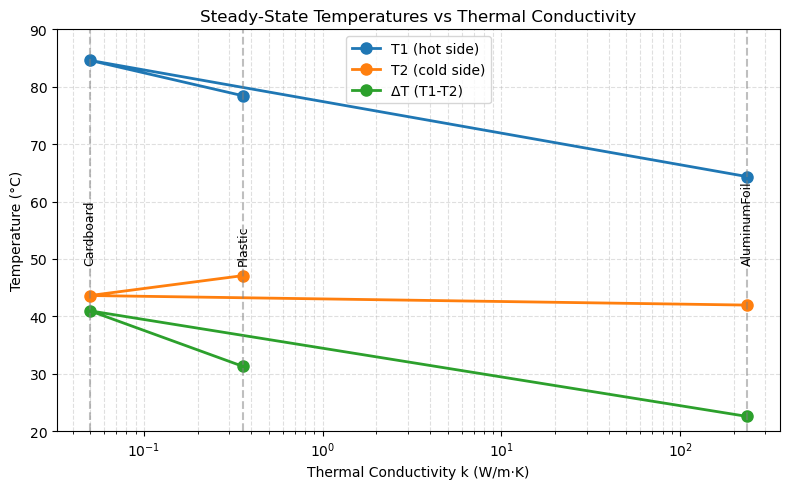

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Known thermal conductivities (W/m-K)
k_values = {
    "Plastic": 0.36,
    "Cardboard": 0.05,
    "AluminumFoil": 237
}

files = {
    "Plastic": "RoomKey_test2.csv",
    "Cardboard": "CorrCardboard_test1.csv",
    "AluminumFoil": "Tinfoil_test2.csv"
}

T1_avgs = []
T2_avgs = []
DT_avgs = []
k_list = []
materials = []

for material, file in files.items():
    df = pd.read_csv(file)

    T1_last6 = df["T1"].tail(6).mean()
    T2_last6 = df["T2"].tail(6).mean()
    DT_last6 = df["T1-T2"].tail(6).mean()

    T1_avgs.append(T1_last6)
    T2_avgs.append(T2_last6)
    DT_avgs.append(DT_last6)
    k_list.append(k_values[material])
    materials.append(material)

# Plot
plt.figure(figsize=(8,5))

plt.semilogx(k_list, T1_avgs, marker='o', markersize=8, linewidth=2,
             label="T1 (hot side)")
plt.semilogx(k_list, T2_avgs, marker='o', markersize=8, linewidth=2,
             label="T2 (cold side)")
plt.semilogx(k_list, DT_avgs, marker='o', markersize=8, linewidth=2,
             label="ΔT (T1-T2)")

# vertical markers at each material k-value
for i, k in enumerate(k_list):
    plt.axvline(x=k, color='grey', linestyle='--', alpha=0.5)
    plt.text(k, 49, materials[i], rotation=90, va='bottom', ha='center', fontsize=9)

plt.xlabel("Thermal Conductivity k (W/m·K)")
plt.ylabel("Temperature (°C)")
plt.title("Steady-State Temperatures vs Thermal Conductivity")
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.ylim(20, 90)
plt.legend()
plt.tight_layout()
plt.show()


### Takeways:
 This plot helps reveal how different materials control heat flow. By observing how T₁, T₂, and ΔT change with conductivity, we can judge whether a material behaves more like an insulator or a conductor 

In real engineering applications like protecting a battery from a hot processor, the goal is to minimize hot spots and control how heat flows through the device.

Poor conductors (cardboard, plastic) trap heat and create large temperature differences.

Good conductors (aluminum foil) spread heat efficiently, reducing thermal gradients and stabilizing the system.

In [57]:
print(T1_avgs)

[np.float64(78.4175), np.float64(84.59416666666668), np.float64(64.33999999999999)]


##  Create a linear regression for $\log_{10}$(thermal conductivity) versus $T_1$, $T_2$, and $\Delta T$ for stainless steel


By plugging in stainless steel’s conductivity (k = 18 W/m·K), we use the regression model to estimate what the hot-side temperature, cold-side temperature, and temperature difference would be if we inserted stainless steel into the setup

In [56]:
import numpy as np

# log10 thermal conductivity values
log_k = np.log10(k_list)

# Linear regressions: y = m*x + b
m1, b1 = np.polyfit(log_k, T1_avgs, 1)   # T1 vs log10(k)
m2, b2 = np.polyfit(log_k, T2_avgs, 1)   # T2 vs log10(k)
m3, b3 = np.polyfit(log_k, DT_avgs, 1)   # ΔT vs log10(k)

print("Slope for T1 vs log10(k):", m1)
print("Slope for T2 vs log10(k):", m2)
print("Slope for ΔT vs log10(k):", m3)

# Predict values for stainless steel (k = 18 W/m·K)
k_steel = 18
x_pred = np.log10(k_steel)

T1_pred = m1 * x_pred + b1
T2_pred = m2 * x_pred + b2
DT_pred = m3 * x_pred + b3

print("\nPredicted T1 for stainless steel (k=18):", T1_pred)
print("Predicted T2 for stainless steel:(k=18)", T2_pred)
print("Predicted ΔT for stainless steel(k=18):", DT_pred)


Slope for T1 vs log10(k): -5.381791015590456
Slope for T2 vs log10(k): -0.7944687373280332
Slope for ΔT vs log10(k): -4.528666753184037

Predicted T1 for stainless steel (k=18): 70.15848811752511
Predicted T2 for stainless steel:(k=18) 43.396513639003885
Predicted ΔT for stainless steel(k=18): 26.860951745147055


T1 slope is negative
Higher k = better heat transfer → the hot side does not heat up as much, because heat is conducted away quickly.

T2 slope is slightly positive or flat
Higher k = cold side warms up faster because it receives heat more easily.

ΔT slope is strongly negative
Better conductivity means the temperature difference collapses.

Afer estimating the effective thermal conductivity for each material using steady-state measurements, it’s important to recognize what the simple Fourier model doesn’t capture. The TCLab hardware contains multiple layers (heater, sensor package, adhesive, material insert, air gaps, etc.), and heat spreads through these components in a three-dimensional pattern. The Energy Balance section below highlights the full set of physical parameters involved in heat transfer through the device. This gives context for why my measured conductivities differ from real material values and why more advanced modeling would be required for high-accuracy prediction

## Energy Balance

Heat is conducted from one sensor to the other through multiple layers of varying thermal conductivity as found in the heat sink, TIP31C transistor heater, TMP36 temperature sensor, as well as the gap between the two heat sinks. In addition, there are 3D aspects to the heaters that should be considered with a more rigorous analysis. A more detailed model would be required to accurately predict the resistance to conductive heat transfer without validating data.

<img src=https://apmonitor.com/pdc/uploads/Main/arduino_comsol.png width="200"><img src=https://apmonitor.com/pdc/uploads/Main/tclab_heater.png width="100">

| __Parameter__ | __Value__ |
|------|------|
| Ambient Temperature $(T_\infty)$ | 23.0 $^oC$ |
| Distance Between Sensors $(\Delta x)$ | 0.015 $m$ |
| Emissivity $(\epsilon)$   | 0.9 |
| Heat Capacity $(c_p)$ | 500 $\frac{J}{kg \, K}$ |
| Convective Heat Transfer Coefficient $(h)$ | 4.05 $\frac{W}{m^2 \, K}$ |
| Mass $(m)$ | 0.004 $kg$ |
| Stefan Boltzmann Constant ($\sigma$) | 5.67e-8 $\frac{W}{m^2-K^4}$ |
| Surface Area ($A$) | 1.2e-3 $m^2$ (12 $cm^2$) |
| Thermal Conductivity $(k)$ | Varies with Material |




<img src=https://apmonitor.com/pdc/uploads/Main/tclab_sac.png width="400">

An energy balance includes energy accumulation $m \, c_p \, \frac{dT}{dt}$, energy in, and energy out. The energy balance includes conduction from $T_1$ (+energy), convection to the ambient air (-energy), and radiative heat transfer (-energy). Use the following equations for an energy balance on $T_2$. 

Conduction (Fourier's Law): $q_{cond} = -k \frac{dT}{dx} \approx -k_c \frac{T_2-T_1}{\Delta x}$

Convective Heat Transfer: $q_{conv} = h \, A \, \left(T_\infty-T_2\right)$

Radiative Heat Transfer: $q_{rad} = \sigma \, \epsilon \, A \, \left((T_\infty+273.15)^4-(T_2+273.15)^4\right)$

Energy Balance: $m \, c_p \, \frac{dT_2}{dt} = q_{cond} + q_{conv} + q_{rad}$

## Composite Thermal Conductivity

Composite thermal conductivity is the effective thermal conductivity of a system made of more than one material layered together.

Determine a composite heat transfer coefficient $k_c$ for each material test with the steady state data points. For steady state, assume that $\frac{dT_2}{dt}=0$. Solve the energy balance equation $0 = q_{conv}+q_{cond}+q_{rad}$ for $k_c$. Evaluate $k_c$  through algebraic rearrangement

Create a semi-log x plot of the ___composite___ thermal conductivity $(k_c)$ versus $T_1$, $T_2$, and $\Delta T$ using an average of the last 6 data points for each of the plastic, metal, and cardboard tests. Use __plt.semilogx__ to create the plot with thermal conductivity as the first argument and the temperatures as the second argument.

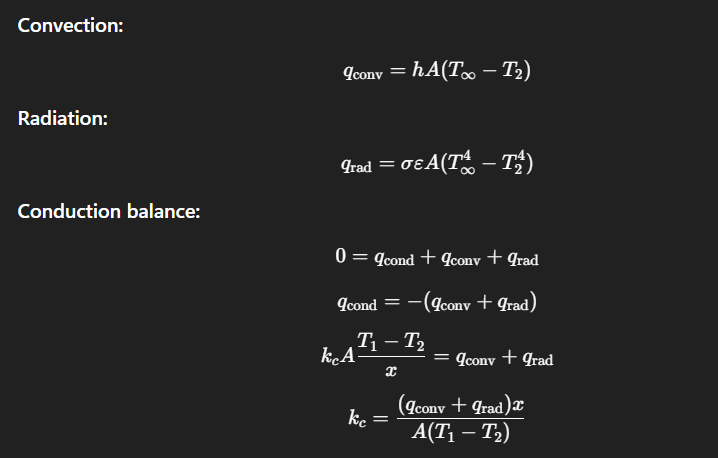

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constants
Tinf = 20 + 273.15       # Ambient temperature (K)
h = 10.0                 # Convective heat transfer coefficient (W/m^2-K)
A = 12.0 / 100.0**2      # Surface area (m^2)
eps = 0.9                # Emissivity
sigma = 5.67e-8          # Stefan-Boltzmann constant
x = 0.015                # Thickness (m)

# Convert to Kelvin
T1 = np.array(T1_avgs) + 273.15    
T2 = np.array(T2_avgs) + 273.15    

# Convection heat loss
qconv = h * A * (Tinf - T2)

# Radiation heat loss
qrad = sigma * eps * A * ( Tinf**4 - T2**4 )

# Composite thermal conductivity kc
kc = (- (qconv + qrad) * x ) / ( A * (T1 - T2) )

print("Composite thermal conductivity kc (W/m·K):")
print(kc)


# Print with material names
for mat, val in zip(materials, kc):
    print(f"{mat}: {val:.3f} W/m·K")

Composite thermal conductivity kc (W/m·K):
[0.20636336 0.13663831 0.23177678]
Plastic: 0.206 W/m·K
Cardboard: 0.137 W/m·K
AluminumFoil: 0.232 W/m·K


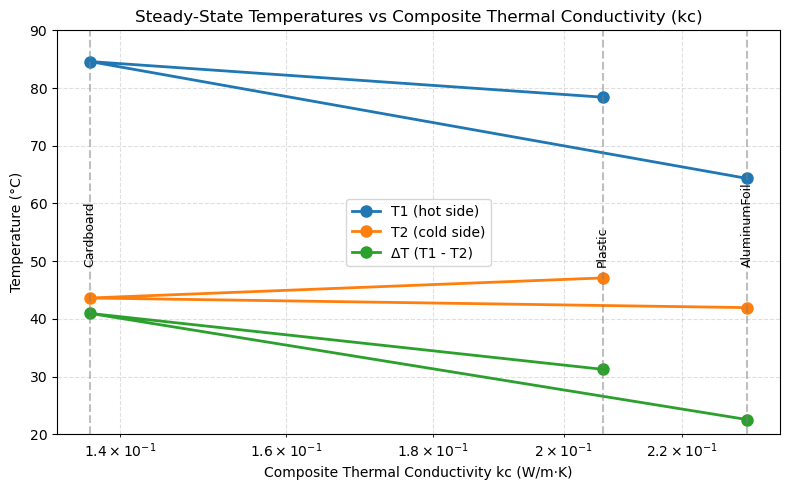

In [64]:
plt.figure(figsize=(8,5))

# Plot T1, T2, ΔT vs kc
plt.semilogx(kc, T1_avgs, marker='o', markersize=8, linewidth=2,
             label="T1 (hot side)")
plt.semilogx(kc, T2_avgs, marker='o', markersize=8, linewidth=2,
             label="T2 (cold side)")
plt.semilogx(kc, DT_avgs, marker='o', markersize=8, linewidth=2,
             label="ΔT (T1 - T2)")

# Add vertical markers with material names
for i, k in enumerate(kc):
    plt.axvline(x=k, color='grey', linestyle='--', alpha=0.5)
    plt.text(k, 49, materials[i], rotation=90,
             va='bottom', ha='center', fontsize=9)

plt.xlabel("Composite Thermal Conductivity kc (W/m·K)")
plt.ylabel("Temperature (°C)")
plt.title("Steady-State Temperatures vs Composite Thermal Conductivity (kc)")
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.ylim(20, 90)
plt.legend()
plt.tight_layout()
plt.show()


### Takeaways

Materials with higher composite thermal conductivity (higher kc) show lower T₁, higher T₂, and a much smaller ΔT, because heat moves more efficiently from the hot side to the cold side.

Poor conductors like cardboard produce the largest temperature difference, with a very hot T₁ and a cool T₂, which is typical of an insulator.

Good conductors like aluminum foil quickly equalize temperatures, causing T₁ to drop, T₂ to rise, and ΔT to collapse..

The kc values are small because the real system is limited by convection and radiation, so the composite heat transfer is dominated by air heat loss rather than pure conduction through the material.


## Solving the Differential Equation

### Purpose
Up to this point, steady-state measurements were used to estimate the effective thermal conductivity of each material. That approach tells me how strongly each material conducts heat once everything has stabilized, but it doesn’t explain how the system evolves over time.

To capture the full temperature response, including how quickly heat flows from heater 1 to the second sensor , now use the composite conductivity together with the convection and radiation terms to build a transient energy balance. This leads to an ordinary differential equation (ODE) that predicts the temperature of sensor T₂ as a function of time. Solving this ODE allows one to compare the model’s predicted temperature curves with the actual experimental data for cardboard, plastic, and aluminum.

**Use the composite thermal conductivity $k_c$ from the prior problem to solve the transient energy balance as an ordinary differential equation (ODE).**

Conduction (Fourier's Law): $q_{cond} = -k \frac{dT}{dx} \approx -k_c \frac{T_2-T_1}{\Delta x}$

Convective Heat Transfer: $q_{conv} = h \, A \, \left(T_\infty-T_2\right)$

Radiative Heat Transfer: $q_{rad} = \sigma \, \epsilon \, A \, \left((T_\infty+273.15)^4-(T_2+273.15)^4\right)$

Energy Balance: $m \, c_p \, \frac{dT_2}{dt} = q_{cond} + q_{conv} + q_{rad}$

The initial condition is the initial temperature of $T_2$. Show the ODE solution for $T_2$ with data for each of the 3 cases (cardboard, plastic, and metal). Plot the measured temperatures and predicted temperatures for each case in a separate subplot. Add appropriate labels to the plot.

### Rearrange ODE
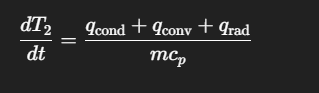
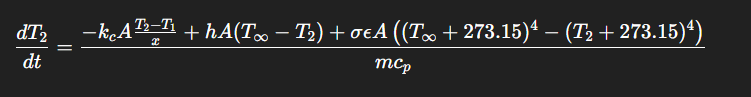

In [67]:
# ODE Function

def dT2_dt(T2, t, T1_func, kc):
    #Constants
    Tinf = 20 + 273.15       # Ambient temperature (K)
    h = 10.0                 # Convective heat transfer coefficient (W/m^2-K)
    A = 12.0 / 100.0**2      # Surface area (m^2)
    eps = 0.9                # Emissivity
    sigma = 5.67e-8          # Stefan-Boltzmann constant
    x = 0.015                # Thickness (m)
    cp = 500                 # Specific heat 
    m = 0.004                # mass (kg)
    
    # T1 at current time (interpolated from data)
    T1 = T1_func(t)

    # Heat transfer equations
    q_cond = -kc * A * (T2 - T1) / x
    q_conv = h * A * (Tinf - T2)
    q_rad = sigma * eps * A * (Tinf**4 - T2**4)

    return (q_cond + q_conv + q_rad) / (m * cp)


In [83]:
# Load data and create interpolation for T1(t) (for plastic room key)
from scipy.interpolate import interp1d

df = pd.read_csv("RoomKey_test2.csv")

t_data = df["Time"].values
T1_data = df["T1"].values + 273.15 #convert to Kelvin
T2_data = df["T2"].values + 273.15 #convert to Kelvin

# Interpolate T1 over time
T1_func = interp1d(t_data, T1_data, fill_value="extrapolate")


In [84]:
# solve the ODE for plastic room key
from scipy.integrate import odeint

# KC for all materials
kc_values = {
    "Plastic": 0.206,    
    "Cardboard": 0.137,
    "AluminumFoil": 0.232
}

# Initial condition for T2(0)
T2_initial = T2_data[0] 

# kc for room key
kc_plastic = kc_values["Plastic"]

# Solve ODE
T2_model = odeint(
    dT2_dt,
    T2_initial,
    t_data,
    args=(T1_func, kc_plastic)
)

print((T2_model - 273.15)[:10])


[[20.834     ]
 [20.65831399]
 [20.56949769]
 [20.6182691 ]
 [20.82094415]
 [21.19158887]
 [21.71645544]
 [22.37208872]
 [23.1374815 ]
 [24.00119018]]


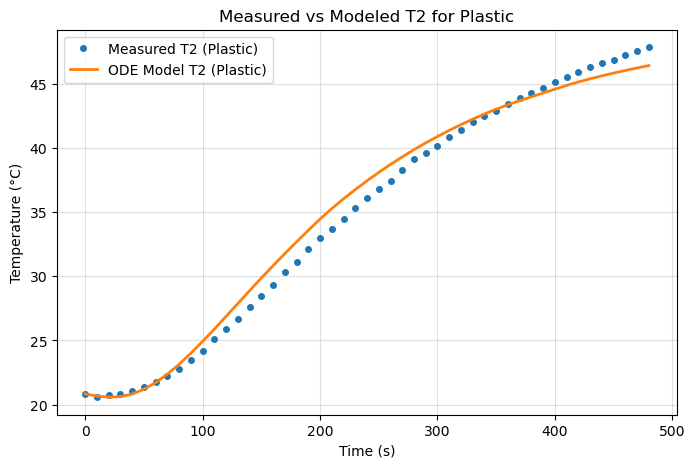

In [85]:
T2_model_C = T2_model.flatten() - 273.15
T2_data_C = T2_data - 273.15

plt.figure(figsize=(8,5))
plt.plot(t_data, T2_data_C, 'o', markersize=4, label="Measured T2 (Plastic)")
plt.plot(t_data, T2_model_C, '-', linewidth=2, label="ODE Model T2 (Plastic)")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Measured vs Modeled T2 for Plastic")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()



### Takeway: 

The model matches the real data closely, capturing the shape and steady-state behavior. Minor differences come from real-world imperfections, but overall it shows the ODE model accurately reflects the thermal behavior of the plastic room key

## Solving ODE for other materials (Cardboard and aluminum foil)

In [81]:
# Load data and create interpolation for T1(t) (for corrugated cardboard)
from scipy.interpolate import interp1d

df = pd.read_csv("CorrCardboard_test1.csv")

t_data = df["Time"].values
T1_data = df["T1"].values + 273.15 #convert to Kelvin
T2_data = df["T2"].values + 273.15 #convert to Kelvin

# Interpolate T1 over time
T1_func = interp1d(t_data, T1_data, fill_value="extrapolate")


# solve the ODE for cardboard
from scipy.integrate import odeint

# KC for all materials
kc_values = {
    "Plastic": 0.206,    
    "Cardboard": 0.137,
    "AluminumFoil": 0.232
}

# Initial condition for T2(0)
T2_initial = T2_data[0] 

# kc forcardboard
kc_cardboard = kc_values["Cardboard"]

# Solve ODE
T2_model = odeint(
    dT2_dt,
    T2_initial,
    t_data,
    args=(T1_func, kc_cardboard)
)

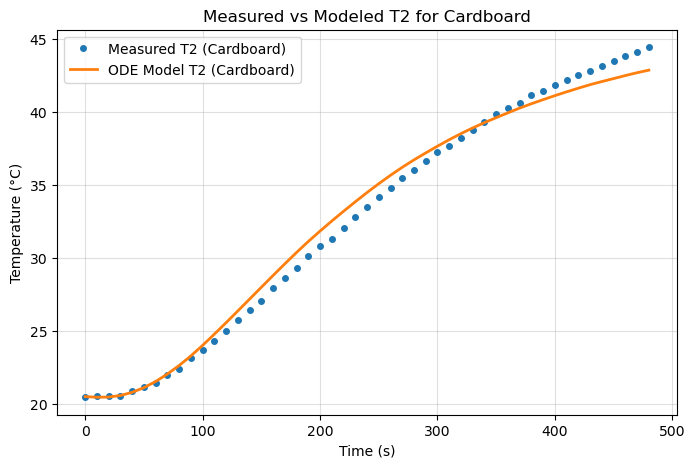

In [82]:
T2_model_C = T2_model.flatten() - 273.15
T2_data_C = T2_data - 273.15

plt.figure(figsize=(8,5))
plt.plot(t_data, T2_data_C, 'o', markersize=4, label="Measured T2 (Cardboard)")
plt.plot(t_data, T2_model_C, '-', linewidth=2, label="ODE Model T2 (Cardboard)")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Measured vs Modeled T2 for Cardboard")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

### Takeway:

Roughly the same fit and level of accuracy as the plastic model

In [87]:
# Load data and create interpolation for T1(t) (Tinfoil)
from scipy.interpolate import interp1d

df = pd.read_csv("Tinfoil_test2.csv")

t_data = df["Time"].values
T1_data = df["T1"].values + 273.15 #convert to Kelvin
T2_data = df["T2"].values + 273.15 #convert to Kelvin

# Interpolate T1 over time
T1_func = interp1d(t_data, T1_data, fill_value="extrapolate")


# solve the ODE for cardboard
from scipy.integrate import odeint

# KC for all materials
kc_values = {
    "Plastic": 0.206,    
    "Cardboard": 0.137,
    "AluminumFoil": 0.232
}

# Initial condition for T2(0)
T2_initial = T2_data[0] 

# kc forcardboard
kc_tinfoil = kc_values["AluminumFoil"]

# Solve ODE
T2_model = odeint(
    dT2_dt,
    T2_initial,
    t_data,
    args=(T1_func, kc_tinfoil)
)

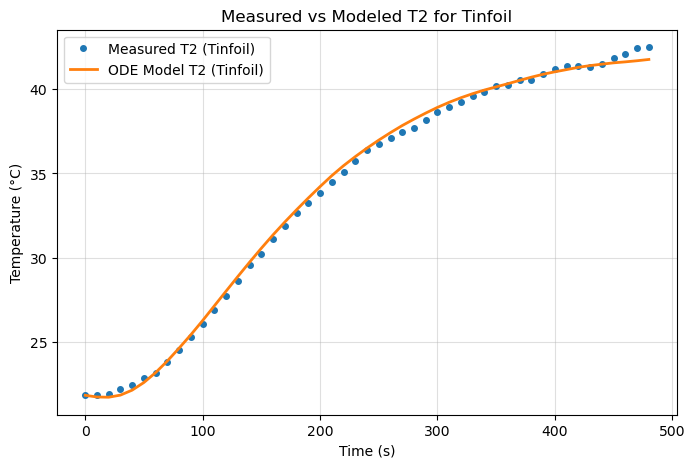

In [88]:
T2_model_C = T2_model.flatten() - 273.15
T2_data_C = T2_data - 273.15

plt.figure(figsize=(8,5))
plt.plot(t_data, T2_data_C, 'o', markersize=4, label="Measured T2 (Tinfoil)")
plt.plot(t_data, T2_model_C, '-', linewidth=2, label="ODE Model T2 (Tinfoil)")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Measured vs Modeled T2 for Tinfoil")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

The tinfoil model fits extremely well. This makes sense because tinfoil has high thermal conductivity, so its behavior is more ideal and easier for the ODE to capture. The close match shows the model is accurately predicting fast heat transfer through a highly conductive material.

### Plot all materials together

In [89]:
def solve_material(filename, material_name):
    import pandas as pd
    from scipy.interpolate import interp1d
    from scipy.integrate import odeint
    import numpy as np

    # Load data
    df = pd.read_csv(filename)
    t_data = df["Time"].values
    T1_data = df["T1"].values + 273.15
    T2_data = df["T2"].values + 273.15

    # Interpolate T1(t)
    T1_func = interp1d(t_data, T1_data, fill_value="extrapolate")

    # kc values 
    kc_values = {
        "Plastic": 0.206,
        "Cardboard": 0.137,
        "AluminumFoil": 0.232
    }

    kc = kc_values[material_name]

    # Initial condition (already Kelvin)
    T2_initial = T2_data[0]

    # Solve ODE
    T2_model = odeint(
        dT2_dt,
        T2_initial,
        t_data,
        args=(T1_func, kc)
    )

    # Convert back to Celsius
    return (
        t_data,
        T2_data - 273.15,
        T2_model.flatten() - 273.15
    )


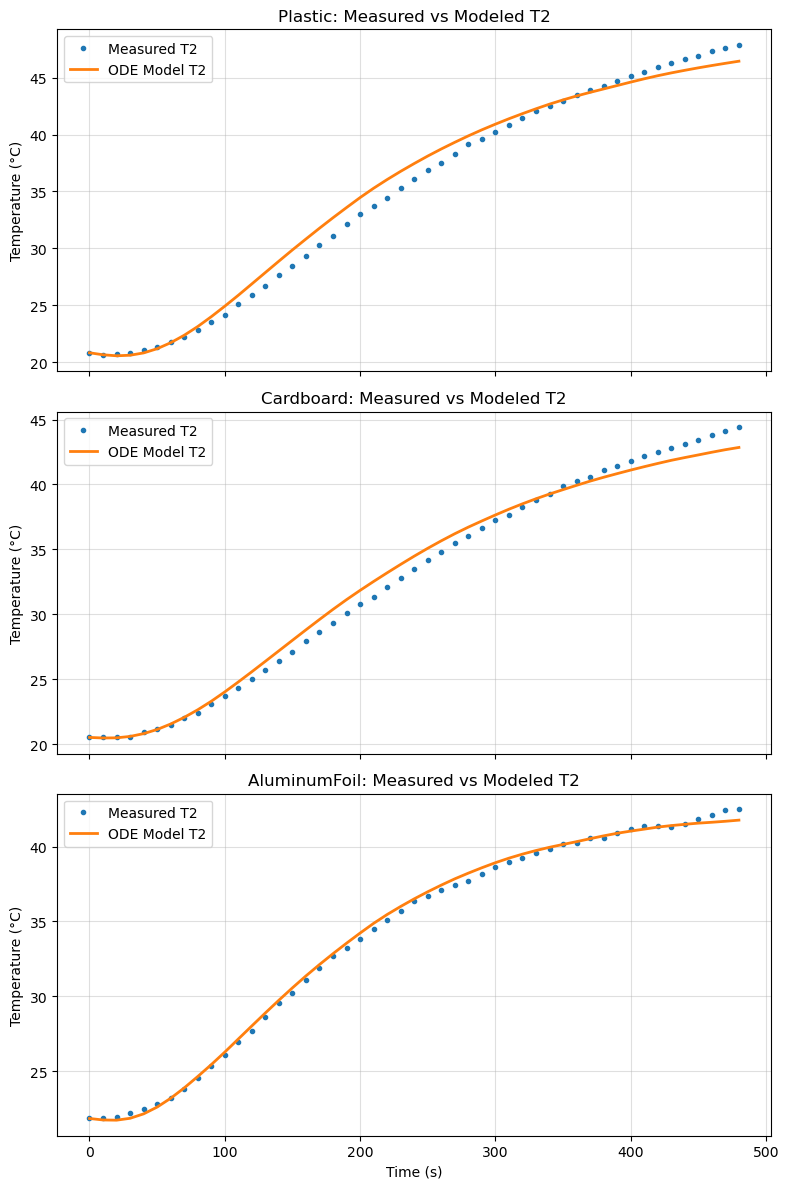

In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8,12), sharex=True)

materials = [
    ("RoomKey_test2.csv", "Plastic"),
    ("CorrCardboard_test1.csv", "Cardboard"),
    ("Tinfoil_test2.csv", "AluminumFoil")
]

for ax, (file, mat) in zip(axes, materials):
    t_data, T2_meas, T2_model = solve_material(file, mat)

    ax.plot(t_data, T2_meas, 'o', markersize=3, label=f"Measured T2")
    ax.plot(t_data, T2_model, '-', linewidth=2, label=f"ODE Model T2")

    ax.set_ylabel("Temperature (°C)")
    ax.set_title(f"{mat}: Measured vs Modeled T2")
    ax.grid(True, alpha=0.4)
    ax.legend()

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()


## Conclusion

This project demonstrated how real sensor data and a physics-based model can be combined to understand and predict heat transfer between two surfaces. By testing plastic, cardboard, and aluminum foil, I quantified how material choice affects both the rate at which heat propagates and the steady-state temperature difference. The workflow tied together practical data science skills — collecting and cleaning time-series data, fitting and validating a model, and estimating physical parameters — with core heat-transfer principles.

A key result is that even a relatively simple energy-balance ODE can capture the dynamics of the system when the parameters are chosen carefully. The model performed best with aluminum foil, which behaved closest to an ideal conductor, and less accurately with insulating materials where real-world effects (gaps, contact resistance) dominate. That contrast reinforced how theoretical assumptions and physical imperfections interact in real experiments.

Overall, this was a complete end-to-end engineering analysis: start with raw measurements, extract material properties, build a model grounded in physical laws, and use it to explain and predict system behavior. The same workflow applies broadly in data science and engineering